This notebook aims at estimating the convergence rate of the any algorithm with respect to $p$ or $q$. 

In [3]:
from pyPLNmodels.utils import build_block_Sigma, C_from_Sigma, sample_PLN, MSE, refined_MSE, MSE, log_stirling
import torch
#from fastPLNmodels.models import IMPS_PLN, log_likelihood, fastPLN, fastPLNPCA, PLNmodel
from pyPLNmodels.models import fastPLN,fastPLNPCA, IMPS_PLN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time 

Device  cpu


In [4]:
import pyPLNmodels

In [5]:

import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.linalg as TLA
from tqdm import tqdm

from pyPLNmodels.utils import (C_from_Sigma, Poisson_reg, batch_log_P_WgivenY, init_C,
                    init_M, init_Sigma, log_stirling)
from pyPLNmodels.VRA import SAGARAD, SAGRAD, SVRGRAD

In [31]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else : 
    device = torch.device('cpu')
    
#device = torch.device('cpu') # think I can't use RTX A5000 right now, will check this later. 
torch.cuda.is_available()

False

In [7]:
%load_ext autoreload

%autoreload 2

In [8]:
d = 1
n = 500;  p = 
q = 10

In [9]:
#torch.manual_seed(0)
Sigma_sampling = 1*torch.from_numpy(build_block_Sigma(p,q))/4 #+ 0.5*torch.eye(p)
true_C = C_from_Sigma(Sigma_sampling, q).to(device)
true_Sigma_sampling = true_C@(true_C.T)
true_beta =torch.randn((d, p), device = device )*0.75
covariates = torch.randn((n,d), device = device)/1
O =  1+torch.zeros((n,p), device = device)
Y, Z,_  = sample_PLN(true_C,true_beta, O, covariates)

In [10]:
torch.max(Y)

tensor(532.)

In [11]:
Y = pd.DataFrame(Y.cpu().numpy())
covariates = pd.DataFrame(covariates.cpu().numpy())
O = pd.DataFrame(O.cpu().numpy())

<AxesSubplot:>

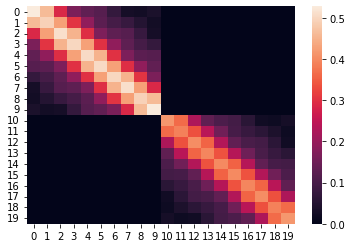

In [12]:
sns.heatmap(true_Sigma_sampling[:400,:400].cpu())

In [78]:
#imps = IMPS_PLN(q=q)
imps.fit(Y,O,covariates, verbose = True, N_iter_max = 200, nb_plateau= 50, batch_size=n)

Intialization ...
C grad None
Initalization done


  0%|          | 1/200 [00:00<02:19,  1.43it/s]

Average log likelihood :  -46.379094463314786


  1%|          | 2/200 [00:01<01:45,  1.88it/s]

Average log likelihood :  -46.32090530691305


...

Average log likelihood :  -43.3564543365531
Average log likelihood :  -43.35747805470742


 80%|███████▉  | 159/200 [00:38<00:07,  5.16it/s]

Average log likelihood :  -43.36883011947316
Average log likelihood :  -43.37382830380241


 80%|████████  | 160/200 [00:39<00:09,  4.10it/s]

Average log likelihood :  -43.37258010559363
Criterion updated :  49 / 50
Average log likelihood :  -43.38160136791703
Criterion updated :  50 / 50
Algorithm stopped after  160  iterations


In [79]:
imps.max_log_like

-43.355856457423144

In [81]:
mypln = fastPLNPCA(q=q)
mypln.fit(Y,O,covariates, good_init = True, verbose = True, N_iter_max = 800, lr = 0.01, tol = 0 ) 

Initialization ...
nb iteration to find the mode:  143
Initialization finished
Iteration number:  0
-------UPDATE-------
Delta:  1
Last ELBO: -407.4735477555005
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
In

Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad N

Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad N

Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Intialization ...
 Random initialization is performed instead
C grad None
Initalization done
Maximum number of iterations reached :  800 last delta =  1.1699729398

In [70]:
 def plotComparison(self, begin, maxLog):
        fig, axes   = plt.subplots(2,1)
        
        xLog =  np.take(self.running_times, np.arange(0,len(self.trueLogLikeList))*self.elapsedEval) 
        yLog = np.log(-np.array(self.trueLogLikeList))
        xELBO = self.running_times
        yELBO = np.log(-np.array(self.normalized_ELBOs))
        
        axes[0].plot(xLog , yLog, label = 'log likelihood')
        axes[0].plot(xELBO, yELBO,label='Negative ELBO')
        axes[0].set_title('Negative ELBO')
        axes[0].set_yscale('log')
        axes[0].set_xlabel('Seconds')
        axes[0].set_ylabel('ELBO')
        axes[0].axhline(maxLog, c = 'red')
        
        axes[0].legend()
        
        axes[1].axhline(maxLog, c = 'red')
        print('xlog :', xLog[begin:])
        print('xelbo', xELBO[begin*self.elapsedEval:])
        axes[1].plot(xLog[begin:], yLog[begin:])
        axes[1].plot(xELBO[begin*self.elapsedEval:], yELBO[begin*self.elapsedEval:])

xlog : [ 10.69730639  11.15008974  11.7256701   12.17205215  12.64748836
  13.11553359  13.54953241  14.0465796   14.45629978  14.8873055
  15.41457939  15.88370943  16.4018569   16.85712981  17.30844426
  17.84665442  18.34183908  18.83360887  19.24898458  19.69816518
  20.108711    20.55780625  20.9735136   21.39628172  21.85660505
  22.34736753  22.79991531  23.27356195  23.73396945  24.15324879
  24.53239751  24.92317915  25.37303662  25.88109398  26.426543
  26.93159962  27.37070942  27.75366592  28.22090173  28.61673284
  29.13200402  29.67344022  30.12589407  30.58969712  31.05787063
  31.51799464  31.93957543  32.3377533   32.7263329   33.14636111
  33.56909657  33.95537114  34.33431768  34.75445747  35.21130705
  35.65225458  36.06713152  36.45543265  36.88052654  37.30735946
  37.72779012  38.10949087  38.48617816  38.8912437   39.28361893
  39.69918251  40.11504221  40.52994633  40.92258048  41.31712174
  41.70971823  42.11337757  42.49833512  42.89220953  43.27726078
  43.6

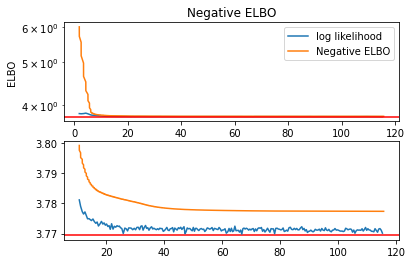

In [82]:
plotComparison(mypln, 15, np.log(-imps.max_log_like))

In [22]:
n = 300
d = 1
#p = 1000
p = 2000 
qs = np.linspace(2, 50, 17).astype(int)
#qs = [50]
#ps = np.linspace(10, 15000, 18).astype(int)
print('qs :', qs)

list_times_imps_q = []

for q in qs: 
    #torch.manual_seed(0)
    print('q : ', q)
    Sigma_sampling = 1*torch.from_numpy(build_block_Sigma(p,q))/4 #+ 0.5*torch.eye(p)
    true_C = C_from_Sigma(Sigma_sampling, q).to(device)
    true_Sigma_sampling = true_C@(true_C.T)
    true_beta =torch.randn((d, p), device = device )*0.75

    covariates = torch.randn((n,d), device = device)/1
    O =  1+torch.zeros((n,p), device = device)
    Y, _,_  = sample_PLN(true_C,true_beta, O, covariates)
    Y = pd.DataFrame(Y.cpu().numpy())
    covariates = pd.DataFrame(covariates.cpu().numpy())
    O = pd.DataFrame(O.cpu().numpy())
    
    imps =IMPS_PLN(q=q)
    imps.fit(Y,O,covariates, verbose = True, N_iter_max = 150, nb_plateau = 1000)
    print('IMPS:')
    print(imps)
    list_times_imps_q.append(imps.running_times[-1])
    sns.heatmap(true_Sigma_sampling[:400,:400].cpu())
    plt.show()
    
    

Device  cpu
qs : [ 2  5  8 11 14 17 20 23 26 29 32 35 38 41 44 47 50]
q :  2
Intialization ...
C grad None
Initalization done


  0%|          | 0/150 [00:04<?, ?it/s]


KeyboardInterrupt: 

Device  cuda


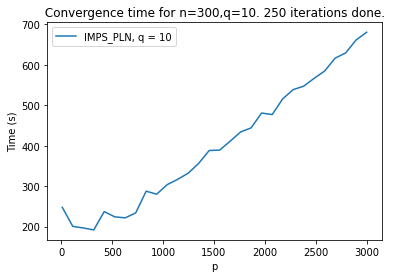

In [150]:
plt.plot(ps, list_times_imps, label = 'IMPS_PLN, q = '+ str(q))
plt.xlabel('p')
plt.ylabel('Time (s)')
plt.title(' Convergence time for n=300,q=10. 250 iterations done. ')
plt.legend()
#plt.savefig('Convergence_analysis_IMPS_PLN_n=300,q=10,250_iterations')

In [156]:
list_times_imps

[247.60059595108032,
 200.50440073013306,
 196.6485505104065,
 191.77661871910095,
 236.99540305137634,
 224.11884236335754,
 221.616473197937,
 233.78124046325684,
 287.53915548324585,
 280.0756673812866,
 303.8065104484558,
 316.93091678619385,
 332.03273248672485,
 356.35276055336,
 388.1026041507721,
 389.05917143821716,
 411.1727855205536,
 433.9818937778473,
 444.13548374176025,
 480.73319602012634,
 477.0237295627594,
 515.763251543045,
 538.5946891307831,
 547.1079080104828,
 566.5156352519989,
 584.5985128879547,
 616.4444603919983,
 629.1868653297424,
 661.3360669612885,
 680.5376958847046]

In [157]:
ps

array([  10,  113,  216,  319,  422,  525,  628,  731,  834,  937, 1041,
       1144, 1247, 1350, 1453, 1556, 1659, 1762, 1865, 1968, 2072, 2175,
       2278, 2381, 2484, 2587, 2690, 2793, 2896, 3000])

In [74]:
from fastPLNmodels.models import log_likelihood
from fastPLNmodels.utils import C_from_Sigma

new_C = C_from_Sigma(model.Sigma, p).detach()
print('log likelihood:', log_likelihood(Y,O,covariates, new_C, model.beta.detach()))

Intialization ...
Initalization done
log likelihood: tensor(-6.1016)
